Evaluating the model


In [48]:
import pandas as pd
import numpy as np
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt


sys.path.append(os.path.abspath(".."))
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV,ParameterGrid,StratifiedKFold
from src.preprocessing import make_preprocessor
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,precision_recall_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
#loading data
df=pd.read_csv(r"C:\Users\92331\Desktop\Customer Churn Prediction Model\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:

#Target and feature columns
X=df.drop(columns=["Churn","customerID"])
Y=df["Churn"].map({"Yes":1,"No":0})



In [5]:
Numeric_columns=X.select_dtypes(include=[float, int]).columns.tolist()
categorical_columns=X.select_dtypes(include=["object"]).columns.tolist()

In [6]:
#trainining and testing 
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)
preprocessor=make_preprocessor(Numeric_columns,categorical_columns)

X_train_preprocessed=preprocessor.fit_transform(X_train)
X_test_preprocessed=preprocessor.transform(X_test)

In [7]:
# base line model training

logistic_reg=LogisticRegression(max_iter=1000)
logistic_reg.fit(X_train_preprocessed,Y_train)
train_accuracy=logistic_reg.score(X_train_preprocessed,Y_train)
print(train_accuracy)


0.8759318423855165


In [8]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_preprocessed, Y_train)

y_pred = log_reg.predict(X_test_preprocessed)
y_prob = log_reg.predict_proba(X_test_preprocessed)[:, 1]


              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

roc_auc_score 0.8402981218837996


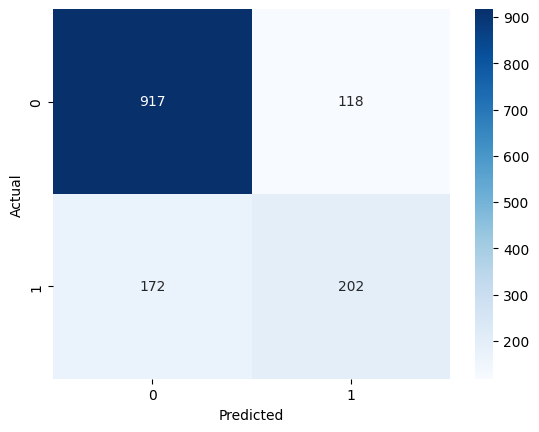

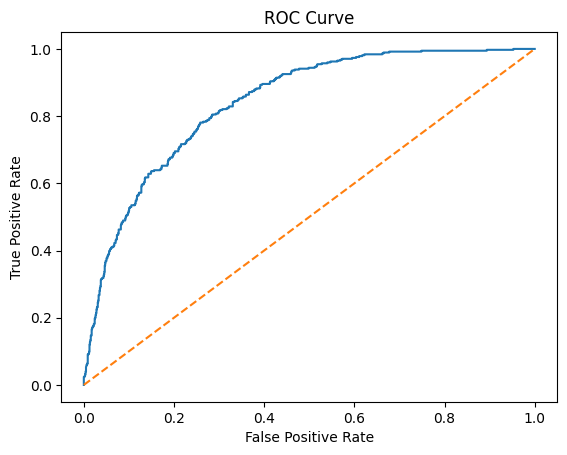

In [9]:
#model evaluation
from sklearn.metrics import roc_curve


Y_test = Y_test.astype(int)
cfs=classification_report(Y_test,y_pred)
print(cfs)
print("roc_auc_score",roc_auc_score(Y_test,y_prob))
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


fpr, tpr, _ = roc_curve(Y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC AUC Score (unchanged by threshold): 0.8402981218837996


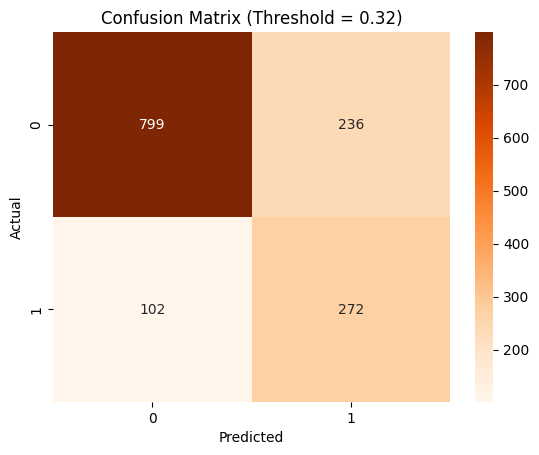

In [10]:
#CHANGIGN THRESHOLD VALUES TO CAPTURE CHURN  CUSTOMERS BETTER
threshold = 0.32
y_pred_thresh = (y_prob >= threshold).astype(int)
print(classification_report(Y_test, y_pred_thresh))

print("ROC AUC Score (unchanged by threshold):", roc_auc_score(Y_test, y_prob))

# Confusion Matrix
cm_thresh = confusion_matrix(Y_test, y_pred_thresh)
sns.heatmap(cm_thresh, annot=True, fmt="d", cmap="Oranges")
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



<h2>Why Recall and F1-Score Matter in Churn Prediction</h2>

<p>
In customer churn prediction, <strong>recall for the churn class (1)</strong> is especially important because it measures how many actual churners the model correctly identifies. Missing a churner means losing a customer and potential revenue.
</p>

<p>
The <strong>F1-score</strong> balances precision and recall, making it a more reliable metric than accuracy for imbalanced datasets like churn, where non-churn customers dominate.
</p>

<h2>Model Evaluation Summary</h2>

<p>
A <strong>Logistic Regression</strong> model was trained to predict customer churn and evaluated using classification metrics and ROC-AUC.
</p>

<ul>
  <li>
    With the default threshold (0.5), the model performed well at predicting non-churn customers but showed lower recall for churn, indicating that many churners were missed.
  </li>
  <li>
    To improve churn detection, the classification threshold was adjusted.
  </li>
  <li>
    After threshold tuning, recall for churn increased significantly, improving the model’s ability to identify customers at risk.
  </li>
  <li>
    This improvement came with a moderate decrease in precision and overall accuracy, reflecting the expected trade-off.
  </li>
  <li>
    The ROC-AUC score remained unchanged, as it is independent of the classification threshold.
  </li>
</ul>

<h2>Key Takeaway</h2>

<p>
By adjusting the decision threshold, the model was optimized for <strong>business relevance rather than raw accuracy</strong>, making it more effective for customer retention use cases where identifying potential churners is a priority.
</p>


<html lang="en">
<head>
  
</head>
<body>
  <h/color="red> Decision Tree</h1>
  <

  
  </div>
</body>
</html>

<h1 style="color: #006400; font-weight: bold;">DECISION TREE CLASSIFIER  — Key Findings</h1>


In [11]:
decison_tree=DecisionTreeClassifier(class_weight="balanced",random_state=42)
param_g={
    "criterion":["gini","entropy"],
    "max_depth":[5,10,15,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,5]
}

scoring = "f1"

grid_search=GridSearchCV(
    estimator=decison_tree,
    param_grid=param_g,
    scoring=scoring,
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_preprocessed,Y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [12]:
print("Best Parameters:", grid_search.best_params_) 
best_dt = grid_search.best_estimator_

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [13]:
y_pred_dt = best_dt.predict(X_test_preprocessed)

print("Decision Tree Performance (Recall Optimized):")
print(f"Accuracy : {accuracy_score(Y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(Y_test, y_pred_dt):.4f}")
print(f"Recall   : {recall_score(Y_test, y_pred_dt):.4f}")
print(f"F1 Score : {f1_score(Y_test, y_pred_dt):.4f}")


Decision Tree Performance (Recall Optimized):
Accuracy : 0.7566
Precision: 0.5285
Recall   : 0.7674
F1 Score : 0.6260


In [15]:
cm=confusion_matrix(Y_test,y_pred_dt)
print(cm)

[[779 256]
 [ 87 287]]


0.7600183419876514


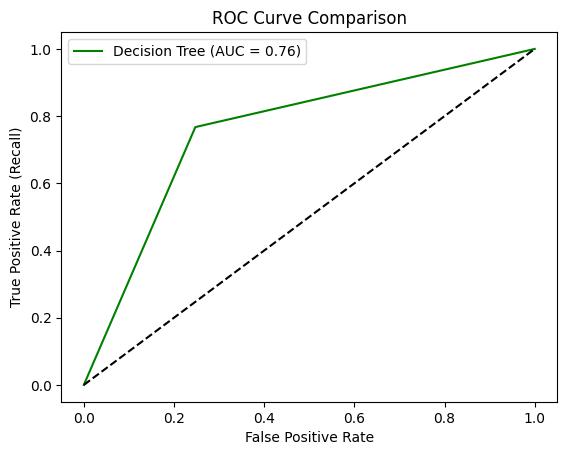

In [20]:
auc_tree = roc_auc_score(Y_test, y_pred_dt)
print(auc_tree)
fpr_tree, tpr_tree, _ = roc_curve(Y_test, y_pred_dt)
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

<h2>📊 Customer Churn Prediction — Key Findings</h2>

<p>
Two machine learning models were tested to predict customer churn: <strong>Logistic Regression</strong> and a <strong>Decision Tree Classifier</strong>. The goal was to see whether the Decision Tree could improve churn detection compared to the baseline model.
</p>

<hr>

<h3>🔍 Overall Model Behavior</h3>

<ul>
  <li>Both models performed at a similar overall level, meaning the Decision Tree did not drastically increase general accuracy.</li>
  <li>The real difference appeared in <strong>how each model handled churn customers</strong> (the most important class).</li>
</ul>

<hr>

<h3>📉 Logistic Regression Insights</h3>

<ul>
  <li>Logistic Regression was more balanced and stable in its predictions.</li>
  <li>It made fewer false alarms, meaning it was more cautious when predicting churn.</li>
  <li>However, it still missed a noticeable portion of customers who actually churned.</li>
</ul>

<p>
➡️ This model is safer but risks letting some at-risk customers leave without intervention.
</p>

<hr>

<h3>🌳 Decision Tree Insights</h3>

<ul>
  <li>The Decision Tree was tuned to prioritize finding churners.</li>
  <li>It successfully identified more customers who were likely to churn compared to Logistic Regression.</li>
  <li>This came at the cost of more false positives — meaning it sometimes flagged customers as churn risks even when they were not.</li>
</ul>

<p>
➡️ This model is more aggressive and better for catching potential churn, but may lead to extra retention efforts on customers who would have stayed anyway.
</p>

<hr>

<h3>⚖️ Business Interpretation</h3>

<ul>
  <li>In churn prediction, <strong>missing a real churner is usually more costly</strong> than contacting a customer who was not going to leave.</li>
  <li>Because of this, the Decision Tree’s behavior aligns better with business goals focused on customer retention.</li>
  <li>The trade-off is increased marketing or retention cost due to additional false alarms.</li>
</ul>

<hr>

<h3>🏁 Final Takeaway</h3>

<p>
While Logistic Regression provides stable and controlled predictions, the <strong>Decision Tree model is more effective for churn detection</strong> because it captures more at-risk customers. For a business trying to reduce customer loss, this makes the Decision Tree the more practical choice despite its tendency to over-predict churn.
</p>

<p>
Further improvements could involve ensemble methods or better class balancing to reduce false positives while keeping churn detection high.
</p>


<h1 style="color: #2c5aa0; font-weight: bold;">Random Forest Classifier  — Key Findings</h1>


In [ ]:
rf=RandomForestClassifier(class_weight="balanced",random_state=42)

param_grid_rf={
    "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,5],
    "max_features":["sqrt","log2"]
}
cv=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)
grid_search_rf=GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    verbose=2
)
grid_search_rf.fit(X_train_preprocessed,Y_train)

best_rf = grid_search_rf.best_estimator_

print("Best Parameters Found:", grid_search_rf.best_params_)



Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\92331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
405 fits failed out of a total of 1215.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
195 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\92331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\92331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\92331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\bas

Best Parameters Found: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


              precision    recall  f1-score   support

           0       0.91      0.66      0.76      1035
           1       0.46      0.81      0.59       374

    accuracy                           0.70      1409
   macro avg       0.68      0.73      0.67      1409
weighted avg       0.79      0.70      0.72      1409



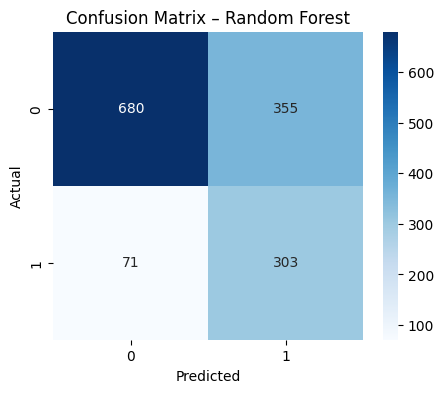

In [39]:
y_pred_rf = best_rf.predict(X_test_preprocessed)
print(classification_report(Y_test,y_pred_rf))
cm = confusion_matrix(Y_test,y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")
plt.show()



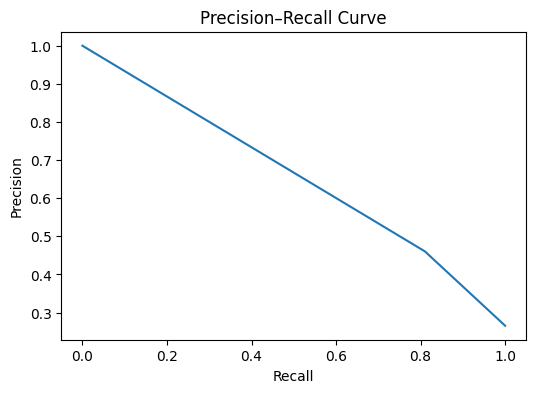

In [49]:
#precision recall tradeoff
precision, recall, thresholds = precision_recall_curve(Y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()


🔎 Random Forest Model – Final Evaluation & Insights

The Random Forest classifier was evaluated on an imbalanced churn dataset using recall-focused metrics to align with business objectives.

📊 Confusion Matrix Analysis

The confusion matrix shows that the model correctly identified a large proportion of churners while maintaining reasonable performance on non-churn customers:

True Positives (Churn correctly identified): 303

False Negatives (Missed churners): 71

True Negatives (Correct non-churn): 680

False Positives (Non-churn predicted as churn): 355

This indicates that the model successfully minimizes false negatives, which is critical in churn prediction where missing a churner can result in direct revenue loss.

📈 Precision–Recall Curve Interpretation

The Precision–Recall curve shows a clear trade-off between precision and recall:

Precision decreases as recall increases, which is expected in imbalanced classification problems.

The smooth downward slope indicates that the model produces well-calibrated probability scores.

High recall regions are achievable, allowing the model to capture most churners at the cost of increased false positives.

This behavior supports threshold tuning depending on business constraints and retention strategy costs.

🧪 Classification Report Summary

Recall (Churn class): 0.81, meaning 81% of actual churners were correctly identified.

Precision (Churn class): 0.46, reflecting a moderate number of false positives.

F1-score (Churn class): 0.59, showing a reasonable balance between precision and recall.

Overall accuracy: 70%, which is acceptable given the class imbalance.

✅ Final Conclusion

The Random Forest model effectively prioritizes churn detection by achieving high recall for the churn class, making it well-suited for retention-focused business decisions. While this comes at the cost of additional false positives, such a trade-off is acceptable in churn prevention scenarios where proactive customer engagement is less costly than customer attrition. The model’s probability outputs further allow flexible threshold tuning to align predictions with business priorities.

<!DOCTYPE html>
<html>
<head>
    <style>
        .final-eval {
            font-family: "Segoe UI", Roboto, Arial, sans-serif;
            background-color: #ffffff;
            padding: 24px;
            border-radius: 10px;
            box-shadow: 0 4px 14px rgba(0,0,0,0.08);
            margin-top: 30px;
            line-height: 1.7;
            max-width: 800px;
            margin: 30px auto;
        }

        .final-eval h2 {
            color: #1f2937;
            border-left: 5px solid #4f46e5;
            padding-left: 12px;
            margin-bottom: 16px;
        }

        .final-eval p {
            color: #374151;
            font-size: 15px;
            margin-bottom: 14px;
        }

        .final-eval ul {
            margin-left: 20px;
            color: #374151;
        }

        .final-eval li {
            margin-bottom: 8px;
        }

        .highlight {
            font-weight: 600;
            color: #16a34a;
        }
    </style>
</head>
<body>
    <div class="final-eval">
        <h2>Final Model Evaluation and Selection</h2>

        <p>
            Three machine learning models—<strong>Logistic Regression</strong>, 
            <strong>Decision Tree</strong>, and <strong>Random Forest</strong>—were evaluated
            for customer churn prediction using precision, recall, F1-score, accuracy,
            and ROC-AUC as performance metrics. Given the imbalanced nature of the dataset
            and the high business cost associated with customer attrition, 
            <strong>recall for the churn class was treated as the primary evaluation criterion</strong>.
        </p>

        <p>
            Logistic Regression achieved the highest overall accuracy and ROC-AUC, indicating
            strong probability ranking and interpretability. However, its relatively low recall
            for churners suggests that a significant proportion of at-risk customers would be missed,
            limiting its effectiveness for proactive churn prevention.
        </p>

        <p>
            The Decision Tree model provided a more balanced trade-off between precision and recall,
            successfully identifying a larger portion of churners while maintaining moderate accuracy.
            Despite this improvement, decision trees are more prone to overfitting and may exhibit
            instability across different data samples.
        </p>

        <p>
            The Random Forest model delivered the <span class="highlight">highest recall</span>,
            capturing the maximum number of churners among all evaluated models. Although this came
            at the cost of lower precision and overall accuracy, such a trade-off is acceptable in
            churn prediction scenarios where the cost of retaining additional customers is
            significantly lower than the cost of losing them.
        </p>

        <p>
            <strong>Final Recommendation:</strong>  
            The <span class="highlight">Random Forest classifier</span> is selected as the final model
            for deployment due to its superior ability to identify customers at risk of churning.
            Its recall-focused performance aligns best with business objectives centered on
            customer retention and revenue protection.
        </p>
    </div>
</body>
</html>

<style>
  .final-eval {
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    background: linear-gradient(135deg, #f9fafb, #ffffff);
    padding: 30px 36px;
    border-radius: 12px;
    box-shadow: 0 8px 24px rgba(0,0,0,0.08);
    margin-top: 40px;
    line-height: 1.8;
    max-width: 800px;
    color: #374151;
  }

  .final-eval h2 {
    color: #1f2937;
    border-left: 6px solid #4f46e5;
    padding-left: 14px;
    margin-bottom: 20px;
    font-size: 24px;
  }

  .final-eval p {
    font-size: 16px;
    margin-bottom: 18px;
  }

  .final-eval ul {
    margin-left: 24px;
    margin-bottom: 18px;
  }

  .final-eval li {
    margin-bottom: 10px;
    font-size: 15.5px;
  }

  .highlight {
    font-weight: 600;
    color: #16a34a;
    background-color: #d1fae5;
    padding: 2px 6px;
    border-radius: 4px;
  }

  /* Optional: subtle hover effect for the whole box */
  .final-eval:hover {
    box-shadow: 0 12px 30px rgba(0,0,0,0.12);
    transition: all 0.3s ease;
  }
</style>

<div class="final-eval">
  <h2>Final Model Evaluation and Selection</h2>
  <p>Three machine learning models—<strong>Logistic Regression</strong>, <strong>Decision Tree</strong>, and <strong>Random Forest</strong>—were evaluated for customer churn prediction using precision, recall, F1-score, accuracy, and ROC-AUC as performance metrics. Given the imbalanced nature of the dataset and the high business cost associated with customer attrition, <strong>recall for the churn class was treated as the primary evaluation criterion</strong>.</p>

  <p>Logistic Regression achieved the highest overall accuracy and ROC-AUC, indicating strong probability ranking and interpretability. However, its relatively low recall for churners suggests that a significant proportion of at-risk customers would be missed, limiting its effectiveness for proactive churn prevention.</p>

  <p>The Decision Tree model provided a more balanced trade-off between precision and recall, successfully identifying a larger portion of churners while maintaining moderate accuracy. Despite this improvement, decision trees are more prone to overfitting and may exhibit instability across different data samples.</p>

  <p>The Random Forest model delivered the <span class="highlight">highest recall</span>, capturing the maximum number of churners among all evaluated models. Although this came at the cost of lower precision and overall accuracy, such a trade-off is acceptable in churn prediction scenarios where the cost of retaining additional customers is significantly lower than the cost of losing them.</p>

  <p><strong>Final Recommendation:</strong> The <span class="highlight">Random Forest classifier</span> is selected as the final model for deployment due to its superior ability to identify customers at risk of churning. Its recall-focused performance aligns best with business objectives centered on customer retention and revenue protection.</p>
</div>


<style>
.model-table {
    width: 100%;
    border-collapse: collapse;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    margin: 20px 0;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
}

.model-table thead {
    background: linear-gradient(90deg, #4f46e5, #6366f1);
    color: white;
}

.model-table th, .model-table td {
    padding: 12px 14px;
    text-align: center;
}

.model-table th {
    font-size: 15px;
    letter-spacing: 0.5px;
}

.model-table tbody tr {
    border-bottom: 1px solid #e5e7eb;
    background-color: #ffffff;
}

.model-table tbody tr:nth-child(even) {
    background-color: #f9fafb;
}

.model-table tbody tr:hover {
    background-color: #eef2ff;
}

.model-table td:first-child {
    font-weight: 600;
    text-align: left;
}

.highlight {
    font-weight: 600;
    color: #16a34a;
}
</style>

<table class="model-table">
    <thead>
        <tr>
            <th>Model</th>
            <th>Precision</th>
            <th>Recall</th>
            <th>F1 Score</th>
            <th>Accuracy</th>
            <th>Best Use Case</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Logistic Regression</td>
            <td>0.63</td>
            <td>0.54</td>
            <td>0.58</td>
            <td class="highlight">0.79</td>
            <td>Explainability</td>
        </tr>
        <tr>
            <td>Decision Tree</td>
            <td>0.53</td>
            <td>0.77</td>
            <td class="highlight">0.63</td>
            <td>0.76</td>
            <td>Balanced Recall</td>
        </tr>
        <tr>
            <td>Random Forest</td>
            <td>0.46</td>
            <td class="highlight">0.81</td>
            <td>0.59</td>
            <td>0.70</td>
            <td>Maximum Churn Capture</td>
        </tr>
    </tbody>
</table>
